In [1]:
## Importing Libraries

import os
import copy
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.models.detection import (fasterrcnn_resnet50_fpn)
from torchvision.models.detection.faster_rcnn import (FastRCNNPredictor)

from torchvision.ops import box_iou

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)



print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [2]:
## Setting Training Device & Paths

device = torch.device("cuda")
print(f"Device : {device}")

ROOT_DIR = Path.cwd().parent

DATASET_DIR = ROOT_DIR / "datasets" / "processed_dataset"

TRAIN_DIR = DATASET_DIR / "images" / "train"
VAL_DIR = DATASET_DIR / "images" / "val"
TEST_DIR = DATASET_DIR / "images" / "test"

MODELS_DIR = ROOT_DIR / "models"/ "FasterRCNN"
MODELS_DIR.mkdir(exist_ok=True)

print("Dataset Loaded.")

Device : cuda
Dataset Loaded.


In [3]:
## Applying Image Tranformers

train_transform = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()])

val_test_transform = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor()])

print("Transforms Ready.")

Transforms Ready.


In [4]:
## Creating Dataset Class

class WeedDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform

        self.images = sorted(list(image_dir.glob("*")))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        label_path = (self.label_dir / f"{image_path.stem}.txt")
        image = Image.open(image_path).convert("RGB")

        width, height = image.size

        boxes = []
        labels = []

        with open(label_path, "r") as f:
            lines = f.readlines()

            for line in lines:
                cls, x, y, w, h = map(float, line.strip().split())

                xmin = (x - w/2) * width
                ymin = (y - h/2) * height

                xmax = (x + w/2) * width
                ymax = (y + h/2) * height

                xmin = xmin * (640 / width)
                xmax = xmax * (640 / width)

                ymin = ymin * (640 / height)
                ymax = ymax * (640 / height)

                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(int(cls) + 1)

        if self.transform:
            image = self.transform(image)

        target = {
                "boxes": torch.tensor(
                boxes,
                dtype=torch.float32),

                "labels": torch.tensor(
                labels,
                dtype=torch.int64)}

        return image, target

In [5]:
## Creating Datasets

train_dataset = WeedDataset(TRAIN_DIR, DATASET_DIR / "labels" / "train", transform=train_transform)
val_dataset = WeedDataset(VAL_DIR, DATASET_DIR / "labels" / "val", transform=val_test_transform)
test_dataset = WeedDataset(TEST_DIR, DATASET_DIR / "labels" / "test", transform=val_test_transform)

print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))

Train : 3948
Val   : 846
Test  : 847


In [6]:
## Creating DataLoaders

def collate_fn(batch):
    return tuple(zip(*batch))

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn)

In [7]:
## Inspecting Batch

images, targets = next(iter(train_loader))

print("Images in Batch :", len(images))
print("Boxes Shape :", targets[0]["boxes"].shape)
print("Labels Shape :", targets[0]["labels"].shape)


print(images[0].shape)
print(targets[0]["boxes"][:5])

Images in Batch : 4
Boxes Shape : torch.Size([2, 4])
Labels Shape : torch.Size([2])
torch.Size([3, 640, 640])
tensor([[144.6032,  23.7037, 611.5875, 612.0634],
        [564.4445,  79.1536, 631.5875, 177.7782]])


In [8]:
## Loading ResNet50 Model

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

in_features = (model.roi_heads.box_predictor.cls_score.in_features)
model.roi_heads.box_predictor = (FastRCNNPredictor(in_features, 13))

model = model.to(device)
print("Faster R-CNN Ready.")

Faster R-CNN Ready.


In [9]:
## Seeting Optimizer

optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Optimizer Ready.")

Optimizer Ready.


In [10]:
## Training Function

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0

    progress_bar = tqdm(loader, total=len(loader), desc="Training", leave=False)

    for images, targets in progress_bar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        total_loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()
        progress_bar.set_postfix(loss=f"{total_loss.item():.4f}")

    epoch_loss = (running_loss / len(loader))

    return epoch_loss

In [11]:
## Validation Function

def validate(model, loader):
    model.train()

    running_loss = 0

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            total_loss = sum(loss for loss in loss_dict.values())

            running_loss += (total_loss.item())

    epoch_loss = (running_loss / len(loader))

    return epoch_loss

In [12]:
## Checkpoint Helpers

CHECKPOINT_PATH = MODELS_DIR / "faster_rcnn_checkpoint.pth"
BEST_MODEL_PATH = MODELS_DIR / "best_faster_rcnn_model.pth"

def save_checkpoint(epoch, model, optimizer, best_acc, history):
    torch.save({"epoch": epoch, "model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(), "best_acc": best_acc, "history": history }, CHECKPOINT_PATH)

def load_checkpoint():
    if CHECKPOINT_PATH.exists():
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        print(
            f"Resuming from Epoch "
            f"{checkpoint['epoch'] + 1}")

        return (checkpoint["epoch"] + 1, checkpoint["best_acc"], checkpoint["history"])

    return 0, float("inf"), {"train_loss": [], "val_loss": []}

In [13]:
## Initializing Training 

NUM_EPOCHS = 10

start_epoch, best_loss, history = load_checkpoint()

print(f"Starting Epoch : {start_epoch}")
print(f"Best Accuracy  : {best_loss:.4f}")

Resuming from Epoch 10
Starting Epoch : 10
Best Accuracy  : 0.1322


In [14]:
## Training Loop

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")

    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss = validate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss

        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Best Model Saved.")

    save_checkpoint(epoch, model, optimizer, best_loss, history)

print("Training Complete.")


Epoch [6/10]


Training:   0%|          | 0/987 [00:00<?, ?it/s]

Train Loss: 0.2038 | Val Loss: 0.1394
Best Model Saved.

Epoch [7/10]


Training:   0%|          | 0/987 [00:00<?, ?it/s]

Train Loss: 0.1900 | Val Loss: 0.1454

Epoch [8/10]


...

Train Loss: 0.1884 | Val Loss: 0.1443

Epoch [9/10]


Training:   0%|          | 0/987 [00:00<?, ?it/s]

Train Loss: 0.1809 | Val Loss: 0.1392
Best Model Saved.

Epoch [10/10]


Training:   0%|          | 0/987 [00:00<?, ?it/s]

Train Loss: 0.1729 | Val Loss: 0.1322
Best Model Saved.
Training Complete.


In [14]:
## Loading Best Model

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

print("Best Model Loaded.")

Best Model Loaded.


Displaying Image 0
Detections : 2


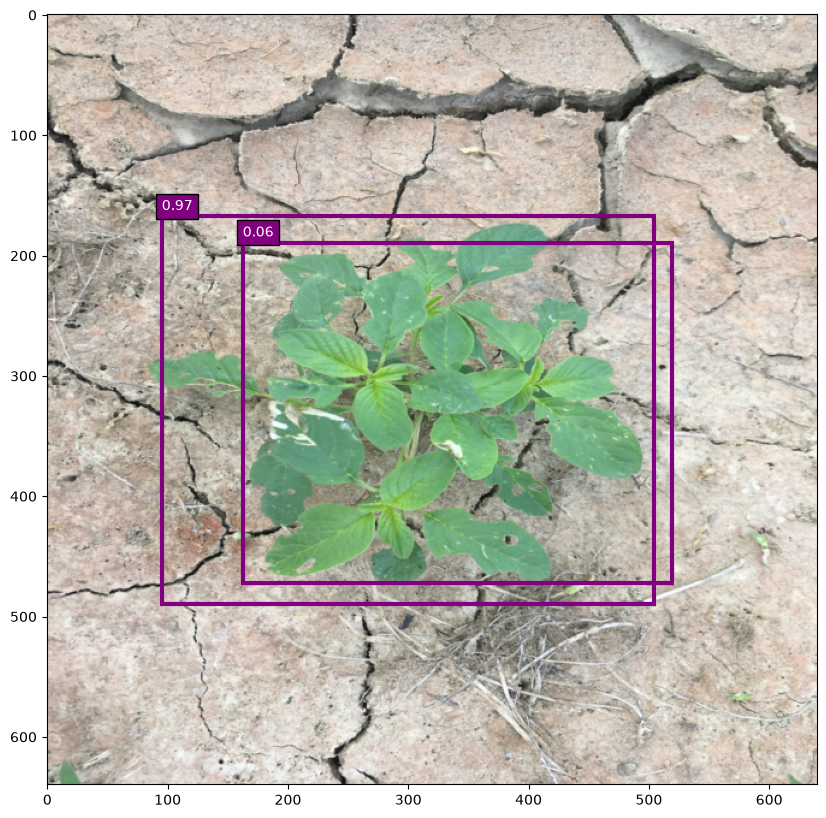

In [15]:
## Evaluations

import matplotlib.pyplot as plt
import matplotlib.patches as patches

model.eval()

images, targets = next(iter(test_loader))

found = False

for idx in range(len(images)):

    image = images[idx].to(device)

    with torch.no_grad():
        prediction = model([image])[0]

    if len(prediction["boxes"]) > 0:

        print(f"Displaying Image {idx}")
        print(f"Detections : {len(prediction['boxes'])}")

        img = image.cpu().permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(figsize=(10,10))
        ax.imshow(img)

        for box, score in zip(
            prediction["boxes"],
            prediction["scores"]
        ):

            if score > 0:

                x1, y1, x2, y2 = box.cpu().numpy()

                rect = patches.Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    edgecolor="purple",
                    linewidth=3
                )

                ax.add_patch(rect)

                ax.text(
                    x1,
                    y1 - 5,
                    f"{score:.2f}",
                    color="white",
                    fontsize=10,
                    bbox=dict(facecolor="purple")
                )

        plt.show()

        found = True
        break

if not found:
    print("No detections found in this batch.")

In [17]:
# %% 
# Faster R-CNN — mAP@50

from torchvision.ops import box_iou
import torch
import numpy as np

model.eval()

IOU_THRESHOLD = 0.50
CONF_THRESHOLD = 0.50

# Store detections and ground truths
all_predictions = []
all_targets = []

with torch.no_grad():

    for images, targets in test_loader:

        images = [img.to(device) for img in images]

        predictions = model(images)

        for prediction, target in zip(predictions, targets):

            # Predictions above confidence threshold
            keep = prediction["scores"] >= CONF_THRESHOLD

            pred_boxes = prediction["boxes"][keep]
            pred_scores = prediction["scores"][keep]
            pred_labels = prediction["labels"][keep]

            gt_boxes = target["boxes"].to(device)
            gt_labels = target["labels"].to(device)

            all_predictions.append({
                "boxes": pred_boxes.cpu(),
                "scores": pred_scores.cpu(),
                "labels": pred_labels.cpu()
            })

            all_targets.append({
                "boxes": gt_boxes.cpu(),
                "labels": gt_labels.cpu()
            })


# ============================================================
# CALCULATE AP FOR EACH CLASS
# ============================================================

classes = sorted(
    set(
        label.item()
        for target in all_targets
        for label in target["labels"]
    )
)

average_precisions = []

for class_id in classes:

    detections = []
    ground_truths = {}

    # Ground truths
    for image_id, target in enumerate(all_targets):

        boxes = target["boxes"]
        labels = target["labels"]

        class_boxes = boxes[
            labels == class_id
        ]

        ground_truths[image_id] = {
            "boxes": class_boxes,
            "matched": [False] * len(class_boxes)
        }

    # Predictions
    for image_id, prediction in enumerate(all_predictions):

        boxes = prediction["boxes"]
        scores = prediction["scores"]
        labels = prediction["labels"]

        mask = labels == class_id

        for box, score in zip(
            boxes[mask],
            scores[mask]
        ):

            detections.append(
                (
                    image_id,
                    score.item(),
                    box
                )
            )

    # Sort highest confidence first
    detections.sort(
        key=lambda x: x[1],
        reverse=True
    )

    if not detections:
        continue

    TP = np.zeros(len(detections))
    FP = np.zeros(len(detections))

    total_gt = sum(
        len(value["boxes"])
        for value in ground_truths.values()
    )

    for i, (image_id, score, pred_box) in enumerate(
        detections
    ):

        gt = ground_truths[image_id]

        if len(gt["boxes"]) == 0:

            FP[i] = 1
            continue

        ious = box_iou(
            pred_box.unsqueeze(0),
            gt["boxes"]
        )[0]

        best_iou, best_idx = ious.max(0)

        best_idx = best_idx.item()

        if (
            best_iou >= IOU_THRESHOLD
            and not gt["matched"][best_idx]
        ):

            TP[i] = 1
            gt["matched"][best_idx] = True

        else:

            FP[i] = 1


    # Cumulative values
    TP = np.cumsum(TP)
    FP = np.cumsum(FP)

    recalls = TP / max(total_gt, 1)

    precisions = TP / np.maximum(
        TP + FP,
        1e-8
    )

    # Precision envelope
    for i in range(
        len(precisions) - 2,
        -1,
        -1
    ):

        precisions[i] = max(
            precisions[i],
            precisions[i + 1]
        )

    # AP calculation
    recall_points = np.concatenate(
        ([0.0], recalls, [1.0])
    )

    precision_points = np.concatenate(
        ([1.0], precisions, [0.0])
    )

    ap = np.sum(
        (
            recall_points[1:]
            - recall_points[:-1]
        )
        * precision_points[1:]
    )

    average_precisions.append(ap)


# ============================================================
# FINAL mAP@50
# ============================================================

mAP50 = (
    np.mean(average_precisions)
    if average_precisions
    else 0.0
)

print("========================================")
print("       FASTER R-CNN mAP@50")
print("========================================")

print(
    f"mAP@50 : {mAP50:.4f}"
)

print(
    f"mAP@50 : {mAP50 * 100:.2f}%"
)

print(
    f"Classes evaluated : {len(average_precisions)}"
)

       FASTER R-CNN mAP@50
mAP@50 : 0.7953
mAP@50 : 79.53%
Classes evaluated : 12
